Data Understanding & Loading


In [0]:
review_df = spark.read.json("/Volumes/workspace/default/fashion_review/Fashion_reviews.jsonl")


Verify **Schema**

In [0]:
review_df.printSchema();

root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: long (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- year: long (nullable = true)



Preview Data

In [0]:
review_df.show(5, truncate=False)
display(review_df)


+----------+------------+-----------+------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------+--------------------+----------------------------+-----------------+----+
|asin      |helpful_vote|parent_asin|rating|text                                                                                                                                                                                                                                                                                                                         |timestamp    |title               |user_id                     |verified_purchase|year|
+----------+------------+-----------+------+--------------------------------------------------------

asin,helpful_vote,parent_asin,rating,text,timestamp,title,user_id,verified_purchase,year
B00LOPVX74,3,B00LOPVX74,5,"I think this locket is really pretty. The inside back is a solid silver depression and the front is a dome that is not solid (knotted). You could use it to store a small photo, lock of hair, etc but I use it when I need to carry medication with me. Closes securely. High quality & very pretty.",1578528394489,Pretty locket,AGBFYI2DDIKXC5Y4FARTYDTQBMFQ,true,2020
B07B4JXK8D,0,B07B4JXK8D,5,Great,1608426246701,A,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,true,2020
B007ZSEQ4Q,3,B007ZSEQ4Q,2,One of the stones fell out within the first 2 weeks of wearing it. Stones smaller than expected.,1432344828000,Two Stars,AHITBJSS7KYUBVZPX7M2WJCOIVKQ,true,2015
B07F2BTFS9,2,B07F2BTFS9,1,Crappy socks. Money wasted. Bought to wear with my tieks. Don’t stay on feet well.,1546289847095,Won’t buy again,AFVNEEPDEIH5SPUN5BWC6NKL3WNQ,true,2018
B00PKRFU4O,0,B00XESJTDE,5,"I LOVE these glasses! They fit perfectly over my regular, rectangular glasses that I always have to wear in order to see. I really appreciate having these pretty and stylish and sturdy sunglasses to wear over my glasses. I'll buy these again and again whenever I need a new pair, which hopefully won't be too soon.",1439476166000,I LOVE these glasses,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,true,2015
B089S8MFCQ,0,B089S8MFCQ,3,Works OK for adults and is not at all kid friendly as stated. Slides down my 5 year olds face.,1603306686690,Adult friendly; Not for small kids,AHTTU2FL6FCNBBAESCJHOHHSSW7A,true,2020
B01MZDN9Z4,0,B01MZDN9Z4,5,Great fit,1497119249157,Five Stars,AFWHJ6O3PV4JC7PVOJH6CPULO2KQ,true,2017
B00N9X4XNU,0,B00N9X4XNU,4,"Would be five stars but they are just too heavy for the size. So cute, gets lots of compliments, but pull the ears down.",1543584620566,Heavy earrings for size of owls but so darn cute!,AEWJXW46LKSW22FWTGRYTLNE7TGA,true,2018
B087M39LVV,0,B087M39LVV,5,What a cute top! Cam wait to wear in warm weather! Got nice,1642721894143,Bright and summer,AEQAYV7RXZEBXMQIQPL6KCT2CFWQ,true,2022
B0799L7FMC,0,B0799L7FMC,2,"Very inexpensive, but too rough and uncomfortable for me, I have to return them..",1532728417117,Scratchy,AFNT6ZJCYQN3WDIKUSWHJDXNND2Q,true,2018


Row Count

In [0]:
review_df.count()

2402363

In [0]:
review_df.columns

['asin',
 'helpful_vote',
 'parent_asin',
 'rating',
 'text',
 'timestamp',
 'title',
 'user_id',
 'verified_purchase',
 'year']

2.Data Quality checks

Null values count

In [0]:
from pyspark.sql.functions import col, sum, when, coalesce, lit
review_df.select([
    coalesce(
        sum(when(col(c).isNull(), 1)),
        lit(0)
    ).alias(c)
    for c in review_df.columns
]).show()


+----+------------+-----------+------+----+---------+-----+-------+-----------------+----+
|asin|helpful_vote|parent_asin|rating|text|timestamp|title|user_id|verified_purchase|year|
+----+------------+-----------+------+----+---------+-----+-------+-----------------+----+
|   0|           0|          0|     0|   0|        0|    0|      0|                0|   0|
+----+------------+-----------+------+----+---------+-----+-------+-----------------+----+



Duplicate count

In [0]:
review_df.count() - review_df.dropDuplicates().count()


24203

In [0]:
review_df.groupBy("user_id", "asin").count() \
         .filter("count > 1").show()


+--------------------+----------+-----+
|             user_id|      asin|count|
+--------------------+----------+-----+
|AHKEX6CG63CP7MS2N...|B073PYNGG3|    2|
|AEKDA2XEOCYI3WULI...|B01A0RMN1G|    2|
|AHDVFMXF5ED6UEPCX...|B07V41MZND|    2|
|AFQFC3DWYB524KQEN...|B075283FTL|    2|
|AHO6FFBQR36HHRM47...|B07DQJK37N|    2|
|AFIOXSSERRD5M6H4L...|B08BRGJNTJ|    2|
|AHDCFRQCT62WDRTYD...|B01B3CIASC|    2|
|AEUUJUJPQ7CPGDIY2...|B07MR1SZR9|    2|
|AEJVUZ5D2IIMAQ2YQ...|B097BJR6P7|    2|
|AGSJUCGJYRIVRE76T...|B01CDULTQI|    2|
|AF7NO6VQLO3FVSCBS...|B00RADVSG0|    2|
|AHU3INL5R7LDS3YE4...|B07TSHCM8P|    2|
|AHO7X7XTEJMZ4HS2O...|B002SRF3BO|    2|
|AEEVFWY7APJJBZC6L...|B07255XNRJ|    2|
|AHLVDNTVSKGB2XNTQ...|B01DZKK0ZQ|    2|
|AG6YHRMNZA6UUZWKL...|B018JVO6T2|    2|
|AELVY4MEH6SWAWXSQ...|B07DHLSBKC|    2|
|AE4FTDOYQ2S6KSJ55...|B07VCVSWZR|    2|
|AFHAJWGDFYOECFFGK...|B093LQ3P85|    2|
|AGF4VBUTC7M27YL2E...|B088WH5QK9|    2|
+--------------------+----------+-----+
only showing top 20 rows


Rating EDA

In [0]:
review_df.groupBy("rating").count().orderBy("rating").show()


+------+-------+
|rating|  count|
+------+-------+
|     1| 295442|
|     2| 167515|
|     3| 235432|
|     4| 334741|
|     5|1369233|
+------+-------+



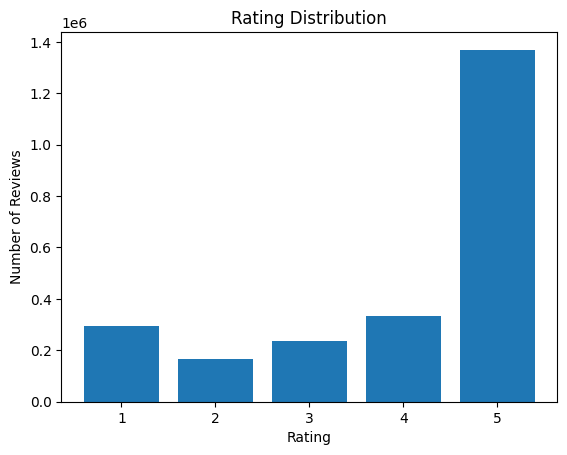

In [0]:
# Rating Distribution (Bar Chart)
# Shows overall customer satisfaction.

rating_df = (
    review_df.groupBy("rating")
    .count()
    .orderBy("rating")
    .toPandas()
)

import matplotlib.pyplot as plt

plt.bar(rating_df["rating"], rating_df["count"])
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.title("Rating Distribution")
plt.show()

In [0]:
#invalid rating check
review_df.filter((col("rating") < 1) | (col("rating") > 5)).count()


0

Descriptive Statistics

In [0]:
review_df.select("rating").describe().show()


+-------+------------------+
|summary|            rating|
+-------+------------------+
|  count|           2402363|
|   mean| 3.963554633500433|
| stddev|1.4326060681020012|
|    min|                 1|
|    max|                 5|
+-------+------------------+



summary for numerical columns


In [0]:
review_df.select(
    "helpful_vote",
    "rating",
    "timestamp",
    "year"
).describe().show()


+-------+------------------+------------------+--------------------+------------------+
|summary|      helpful_vote|            rating|           timestamp|              year|
+-------+------------------+------------------+--------------------+------------------+
|  count|           2402363|           2402363|             2402363|           2402363|
|   mean|0.5488808310817308| 3.963554633500433|1.550083438127175...|2018.6277182091133|
| stddev|3.6591190606889468|1.4326060681020012|6.368744290192754E10| 2.026439621388775|
|    min|                 0|                 1|       1420070625000|              2015|
|    max|               714|                 5|       1694402678515|              2023|
+-------+------------------+------------------+--------------------+------------------+



summary for categorical columns

In [0]:
review_df.groupBy("verified_purchase").count().show()


+-------+-------------------+-------------------+--------------------+
|summary|               asin|        parent_asin|             user_id|
+-------+-------------------+-------------------+--------------------+
|  count|            2402363|            2402363|             2402363|
|   mean|2.960200674121951E9|2.706888240021739E9|                NULL|
| stddev| 3.16435761979265E9|3.208883182672396E9|                NULL|
|    min|         0000099813|         0000099813|AE22236AFRRSMQIKG...|
|    max|         B0CF58YC9F|         B0CKR7QKWB|AHZZZZ76NI5YF4RP5...|
+-------+-------------------+-------------------+--------------------+



In [0]:
review_df.groupBy("asin").count() \
         .orderBy("count", ascending=False).show(10)


+----------+-----+
|      asin|count|
+----------+-----+
|B000GAWSDG| 5344|
|B000FIS5U4| 2101|
|B0163N2T38| 1470|
|B07P7M18C6| 1357|
|B010GJJ5UK|  973|
|B07NQRWW79|  768|
|B01MZF6LL2|  749|
|B07XWQ99TZ|  749|
|B07359QQXT|  735|
|B015YV43DY|  721|
+----------+-----+
only showing top 10 rows


In [0]:
review_df.groupBy("parent_asin").count().show()

+-----------+-----+
|parent_asin|count|
+-----------+-----+
| B082XWNLT3|    1|
| B0B29L3D79|    1|
| B09M6X2SMY|    4|
| B06XDM6Y6Z|    1|
| B016H0PWA4|    1|
| B09CPXG95M|    2|
| B00D5H8MHS|   77|
| B09RMR5S4J|   76|
| B00FEPFPO2|    2|
| B073JJQ2KP|   17|
| B00LMUA8MC|   60|
| B01DFK3RI8|    1|
| B08GZ16DX3|   16|
| B06WD7ZNX6|   18|
| B083364P67|    7|
| B01IFAOH9G|   21|
| B06XCLRFCW|    1|
| B01KC7PV72|    1|
| B01M24LHBR|    1|
| B00SJJ4SHA|    1|
+-----------+-----+
only showing top 20 rows


In [0]:
from pyspark.sql.functions import countDistinct

review_df.select(
    countDistinct("asin").alias("unique_asin"),
    countDistinct("parent_asin").alias("unique_parent_asin"),
    countDistinct("user_id").alias("unique_users")
).show()


+-----------+------------------+------------+
|unique_asin|unique_parent_asin|unique_users|
+-----------+------------------+------------+
|     855302|            807542|     1958111|
+-----------+------------------+------------+



In [0]:
review_df.groupBy("rating").count() \
         .orderBy("count", ascending=False).limit(1).show()


+------+-------+
|rating|  count|
+------+-------+
|     5|1369233|
+------+-------+



In [0]:
from pyspark.sql.functions import length

review_df.select(
    avg(length("text")).alias("avg_text_length"),
    max(length("text")).alias("max_text_length"),
    min(length("text")).alias("min_text_length")
).show()


Exploratory Analysis and Patterns

Verified Purchase Analysis

In [0]:
review_df.groupBy("verified_purchase").count().show()


+-----------------+-------+
|verified_purchase|  count|
+-----------------+-------+
|             true|2252750|
|            false| 149613|
+-----------------+-------+



In [0]:
from pyspark.sql.functions import avg

review_df.groupBy("verified_purchase") \
         .agg(avg("rating").alias("avg_rating")) \
         .show()


+-----------------+------------------+
|verified_purchase|        avg_rating|
+-----------------+------------------+
|             true| 3.964114970591499|
|            false|3.9551175365777036|
+-----------------+------------------+



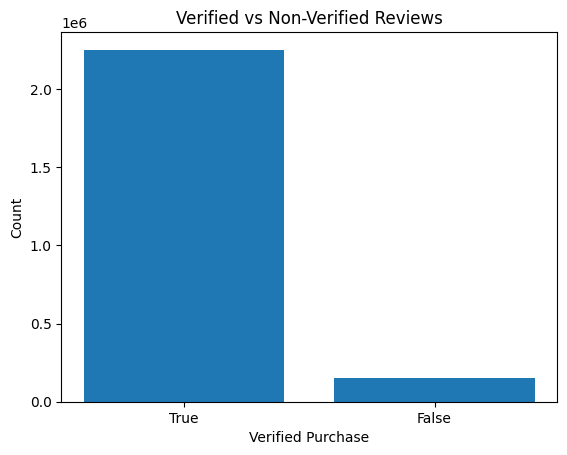

In [0]:
verified_df = review_df.groupBy("verified_purchase").count()
pdf = verified_df.toPandas()

plt.figure()
plt.bar(pdf["verified_purchase"].astype(str), pdf["count"])
plt.xlabel("Verified Purchase")
plt.ylabel("Count")
plt.title("Verified vs Non-Verified Reviews")
plt.show()

Helpful Vote Analysis

In [0]:
review_df.select("helpful_vote").describe().show()


+-------+------------------+
|summary|      helpful_vote|
+-------+------------------+
|  count|           2402363|
|   mean|0.5488808310817308|
| stddev|3.6591190606889468|
|    min|                 0|
|    max|               714|
+-------+------------------+



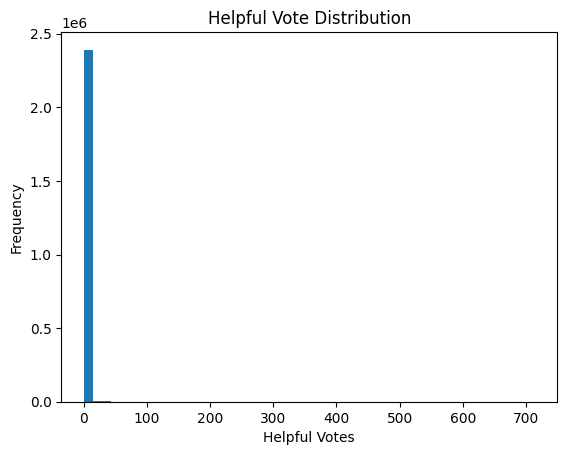

In [0]:
pdf = review_df.select("helpful_vote").toPandas()

plt.figure()
plt.hist(pdf["helpful_vote"], bins=50)
plt.xlabel("Helpful Votes")
plt.ylabel("Frequency")
plt.title("Helpful Vote Distribution")
plt.show()


In [0]:
review_df.filter(col("helpful_vote") > 50).show(truncate=False)


+----------+------------+-----------+------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [0]:
review_df.stat.corr("rating", "helpful_vote")

-0.0009321368208155407

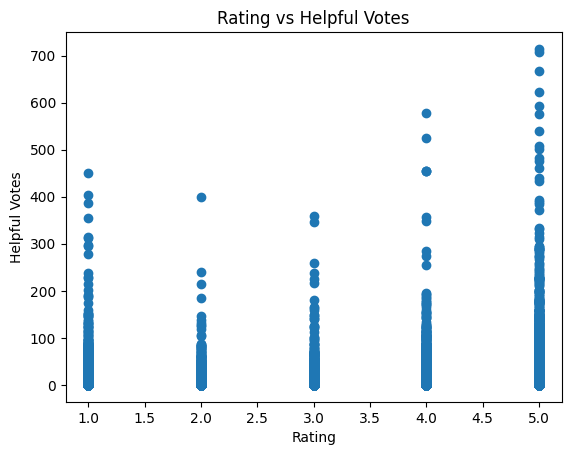

In [0]:
pdf = review_df.select("rating", "helpful_vote").toPandas()

plt.figure()
plt.scatter(pdf["rating"], pdf["helpful_vote"])
plt.xlabel("Rating")
plt.ylabel("Helpful Votes")
plt.title("Rating vs Helpful Votes")
plt.show()


Text Column EDA

In [0]:
from pyspark.sql.functions import length

review_df = review_df.withColumn("text_length", length("text"))


In [0]:
review_df.select("text_length").describe().show()


+-------+------------------+
|summary|       text_length|
+-------+------------------+
|  count|           2402363|
|   mean|139.76805670083996|
| stddev|185.97208511222948|
|    min|                 0|
|    max|             10657|
+-------+------------------+



In [0]:
from pyspark.sql.functions import col

review_df.filter(col("text_length") < 5).count()


28557

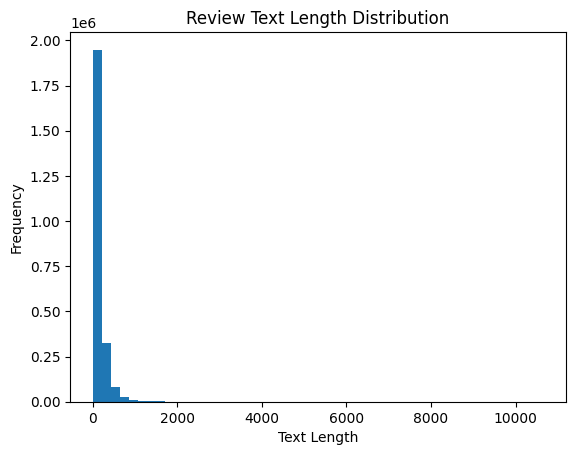

In [0]:
pdf = review_df.select("text_length").toPandas()

plt.figure()
plt.hist(pdf["text_length"], bins=50)
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.title("Review Text Length Distribution")
plt.show()


Title Analysis

In [0]:
review_df.filter(col("title").isNull()).count()


0

In [0]:
review_df = review_df.withColumn("title_length", length("title"))
review_df.select("title_length").describe().show()


+-------+------------------+
|summary|      title_length|
+-------+------------------+
|  count|           2402363|
|   mean|20.451659470279886|
| stddev|16.292211977092244|
|    min|                 1|
|    max|               299|
+-------+------------------+



Time-Based EDA

In [0]:
#Convert UNIX timestamp → date
from pyspark.sql.functions import from_unixtime, to_date

review_df = review_df.withColumn(
    "review_date",
    to_date(from_unixtime("timestamp"))
)


In [0]:
review_df.groupBy("year").count().orderBy("year").show()


+----+------+
|year| count|
+----+------+
|2015|128171|
|2016|288585|
|2017|371900|
|2018|369714|
|2019|412058|
|2020|312235|
|2021|309733|
|2022|173972|
|2023| 35995|
+----+------+



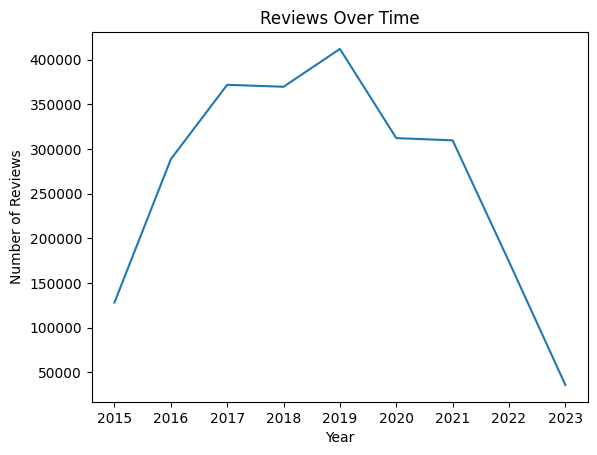

In [0]:
time_df = review_df.groupBy("year").count().orderBy("year")
pdf = time_df.toPandas()

plt.figure()
plt.plot(pdf["year"], pdf["count"])
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.title("Reviews Over Time")
plt.show()


In [0]:
review_df.groupBy("review_date").count().orderBy("review_date").show()


+------------+-----+
| review_date|count|
+------------+-----+
|+46970-03-31|    1|
|+46970-04-02|    3|
|+46970-04-04|    1|
|+46970-04-09|    1|
|+46970-04-11|    1|
|+46970-04-12|    1|
|+46970-04-13|    1|
|+46970-04-14|    1|
|+46970-04-15|    1|
|+46970-04-16|    1|
|+46970-04-24|    1|
|+46970-04-25|    1|
|+46970-04-27|    1|
|+46970-04-30|    1|
|+46970-05-07|    1|
|+46970-05-14|    1|
|+46970-05-18|    1|
|+46970-05-20|    1|
|+46970-05-23|    1|
|+46970-05-27|    1|
+------------+-----+
only showing top 20 rows


User Behavior Analysis

In [0]:
review_df.groupBy("user_id").count() \
         .orderBy("count", ascending=False).show()


+--------------------+-----+
|             user_id|count|
+--------------------+-----+
|AGZZXSMMS4WRHHJRB...|  311|
|AG73BVBKUOH22USSF...|  210|
|AEYVPPWR4CIKWX4BG...|  176|
|AG3HKK7MIKRQ7DOTN...|  145|
|AFQQQ5LGNSQUEBGDC...|  145|
|AH5HSMUMRJRDWBPFD...|  116|
|AH665SQ6SQF6DXAGY...|  112|
|AEGYU6OM2X66SMZN6...|  110|
|AFKZESU3PTCQ2UVDB...|  109|
|AEULD6UDDD7XSH2HX...|  108|
|AGDJ4U4GGIQ6AJLIB...|   95|
|AHPG65LKS3QKRWDUW...|   94|
|AHPG65LKS3QKRWDUW...|   83|
|AHGIDR4IJFS23Q4GT...|   82|
|AFKZESU3PTCQ2UVDB...|   80|
|AHV6QCNBJNSGLATP5...|   78|
|AEORT2SOUGKL76PYW...|   74|
|AECTRGMRKOGAYIV3Y...|   73|
|AEXYLV5YOYWSLGG47...|   69|
|AEIFXWDWF3NU6Y5L5...|   68|
+--------------------+-----+
only showing top 20 rows


Product-Level Analysis

In [0]:
review_df.groupBy("asin").count() \
         .orderBy("count", ascending=False).show()


+----------+-----+
|      asin|count|
+----------+-----+
|B000GAWSDG| 5344|
|B000FIS5U4| 2101|
|B0163N2T38| 1470|
|B07P7M18C6| 1357|
|B010GJJ5UK|  973|
|B07NQRWW79|  768|
|B01MZF6LL2|  749|
|B07XWQ99TZ|  749|
|B07359QQXT|  735|
|B015YV43DY|  721|
|B0132NANCG|  693|
|B017U1FDM6|  685|
|B0045H0L1W|  679|
|B01IUTMWQW|  636|
|B084ZY91GH|  612|
|B00J4JKPBC|  538|
|B015JHPKS0|  531|
|B08JV3PBH6|  526|
|B00TT635R6|  523|
|B06W9NJLF6|  522|
+----------+-----+
only showing top 20 rows


In [0]:
review_df.groupBy("parent_asin").count().show()


+-----------+-----+
|parent_asin|count|
+-----------+-----+
| B082XWNLT3|    1|
| B0B29L3D79|    1|
| B09M6X2SMY|    4|
| B06XDM6Y6Z|    1|
| B016H0PWA4|    1|
| B09CPXG95M|    2|
| B00D5H8MHS|   77|
| B09RMR5S4J|   76|
| B00FEPFPO2|    2|
| B073JJQ2KP|   17|
| B00LMUA8MC|   60|
| B01DFK3RI8|    1|
| B08GZ16DX3|   16|
| B06WD7ZNX6|   18|
| B083364P67|    7|
| B01IFAOH9G|   21|
| B06XCLRFCW|    1|
| B01KC7PV72|    1|
| B01M24LHBR|    1|
| B00SJJ4SHA|    1|
+-----------+-----+
only showing top 20 rows


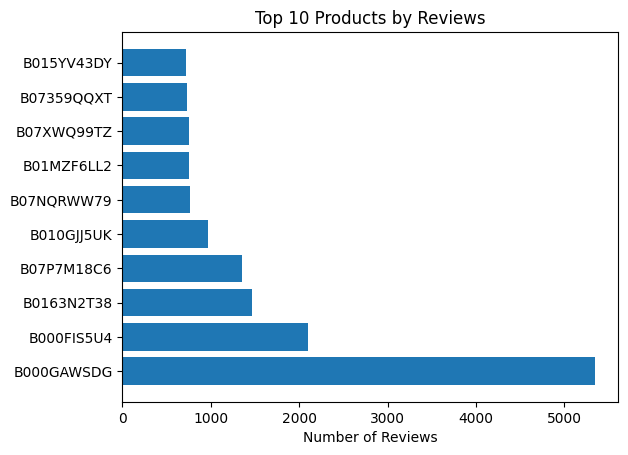

In [0]:
top_asin_df = review_df.groupBy("asin").count() \
                       .orderBy("count", ascending=False) \
                       .limit(10)

pdf = top_asin_df.toPandas()

plt.figure()
plt.barh(pdf["asin"], pdf["count"])
plt.xlabel("Number of Reviews")
plt.title("Top 10 Products by Reviews")
plt.show()


Outlier Detection

In [0]:
review_df.filter(col("text_length") > 2000).count()


1857

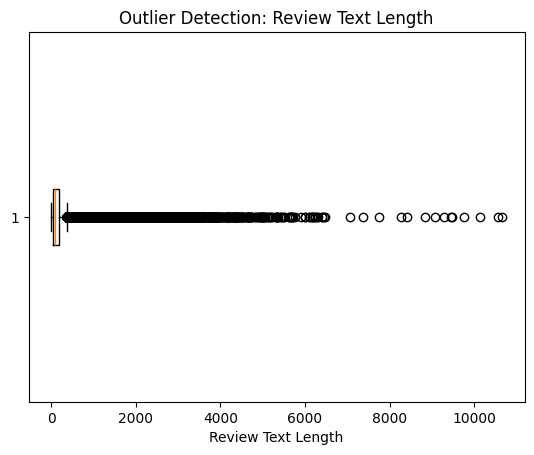

In [0]:
pdf = review_df.select("text_length").toPandas()

import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(pdf["text_length"], vert=False)
plt.xlabel("Review Text Length")
plt.title("Outlier Detection: Review Text Length")
plt.show()


In [0]:
review_df.filter((col("helpful_vote") > 100) & (col("rating") <= 2)).count()


58

Observation,insights

1:row count 2402363,columns:10
2:Null values-0,duplicates:24203,invalid entries(rating)-0
3:Descriptive statistics:
a}numerical column
	mean rating - 3.96
	mean year - 2018
b)categorical column
mean verified purchase per asin - 2.96
mean verified purchase per parent-asin - 2.7
Highest count of reviews for asin(B000GAWSDG) - 5344
Highest count of reviews for parent asin(B00D5H8MHS)-77
unique_asin|-855302
unique_parent_asin - 807542
unique_users|-1958111
Most frequent rating - 5 ,count-1369233
4.Exploratory Analysis and patterns

+-----------------+-------+
|verified_purchase|  count|
+-----------------+-------+
|             true|2252750|
|            false| 149613|
+-----------------+-------+

+-----------------+------------------+
|verified_purchase|        avg_rating|
+-----------------+------------------+
|             true| 3.964114970591499|
|            false|3.9551175365777036|
+-----------------+------------------+

Avg.rating for verified_purchase is good

mean text_length of review = 139.77
count of reviews with text_length < 5 = 28557
highest count of review in year -2019
count of reviews with text_length > 2000 = 1857